# ESS 배터리 수명 예측 — 모델 개발 및 평가

울산 1반 U018 원종현

초기 100사이클의 정보로 배터리의 전체 Cycle Life를 예측하는 회귀 모델을 개발한다. Batch 1에서 모델과 피처군을 선택하고 학습한 뒤, Batch 2에서 최종 성능을 평가한다. 같은 모델을 Batch 3에도 적용해 배치 간 일반화 성능을 확인한다.

이 노트북은 `src.train`의 학습 결과를 표와 그래프로 확인하고 해석한다. 완료된 결과가 없거나 원본·설정·실행 코드·저장 결과가 달라졌으면 후보 비교부터 다시 실행한다. 모든 작업이 완료되고 입력과 결과가 그대로인 경우에는 저장된 결과를 재사용한다. 명시적으로 전체 실험을 다시 실행하려면 아래 명령을 사용한다.

```bash
uv run python -m src.train
```

진행 순서: 실행 환경 확인 → 후보 비교 → 최종 후보 확인 → 성능표 확인 → 예측 오차 분석.


In [1]:
from pathlib import Path
import sys
import json
# 노트북 실행 위치가 저장소 루트 또는 notebooks여도 프로젝트 경로를 찾는다.
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src/preprocess.py').exists()))
sys.path.insert(0, str(ROOT))
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib import font_manager
font_path = Path('/System/Library/Fonts/AppleSDGothicNeo.ttc')
if font_path.exists():
    font_manager.fontManager.addfont(str(font_path))
    plt.rcParams['font.family'] = ['DejaVu Sans', 'Apple SD Gothic Neo']
plt.rcParams.update({'axes.unicode_minus': False, 'figure.figsize': (11, 4), 'axes.spines.top': False, 'axes.spines.right': False})
COLORS = {'B1': '#167c80', 'B2': '#dd7745', 'B3': '#6162aa'}


In [2]:
from src.train import main, results_are_current

# 입력 변경이나 불완전한 실행을 확인하고 필요한 경우 다시 학습한다.
if not results_are_current():
    main()
else:
    print('입력과 결과가 일치하는 완료된 실험을 불러옵니다.')


Extracting B1


Extracting B2


Extracting B3


batch  raw  usable  excluded        mean  median        std   min    max   q25    q75  short  long  short_pct  long_pct  outlier_low_fence  outlier_high_fence lower_outliers                                                           upper_outliers  knee_n  knee_frac_med  accel_med  q_gain_pct
   B1   46      36        10  788.416667   772.5 148.695734 534.0 1074.0 681.0  871.5      0     5   0.000000 13.888889             395.25             1157.25             []                                                                       []      36       0.750937  10.162228   88.888889
   B2   47      39         8  565.743590   472.0 222.201629 392.0 1186.0 439.5  508.5     28     3  71.794872  7.692308             336.00              612.00             [] [B2-C08, B2-C09, B2-C10, B2-C33, B2-C34, B2-C35, B2-C44, B2-C45, B2-C46]      39       0.750307  10.234894   64.102564
   B3   46      43         3 1051.976744  1002.0 313.370577 541.0 1935.0 828.0 1150.5      0    22   0.000000 51.162791  

{
  "q1": [
    {
      "batch": "B1",
      "below_800_pct": 55.55555555555556,
      "cv_pct": 18.860044527984133,
      "skew": 0.30005260559336955
    },
    {
      "batch": "B2",
      "below_800_pct": 82.05128205128204,
      "cv_pct": 39.276031300406295,
      "skew": 1.6368300724817186
    },
    {
      "batch": "B3",
      "below_800_pct": 13.953488372093023,
      "cv_pct": 29.788736174579395,
      "skew": 1.340440051959202
    }
  ],
  "q2": [
    {
      "batch": "B1",
      "n": 36,
      "q2_median": 1.078399,
      "q100_median": 1.08001025,
      "growth_median_pct": 0.22024363268793312,
      "early_slope_median_mah": -0.015789709348626665,
      "pre_knee_median_mah": -0.07402433534931518,
      "post_knee_median_mah": -0.79314710315835,
      "knee_cycle_median": 577.9060606060606,
      "retention_50": 98.59201017961428,
      "retention_75": 95.45341116592246,
      "retention_90": 88.80381054126141
    },
    {
      "batch": "B2",
      "n": 39,
      "q2_medi

...

candidate completed xgboost


candidate completed lightgbm


candidate completed catboost


selected bayesian_ridge paper_discharge6 valid MAPE 5.125197092474987


{
  "selected": {
    "model": "bayesian_ridge",
    "family": "paper_discharge6",
    "features": [
      "dq_logmin",
      "dq_logvar",
      "dq_logskew",
      "dq_logkurtosis",
      "q2",
      "q_max_minus_q2"
    ],
    "criterion": "development nested policy CV MAPE",
    "CV_MAPE": 6.275854460816518,
    "parameters": {}
  },
  "Train_CV_MAPE_mean": 5.327928190108665,
  "Train_CV_MAPE_std": 1.4103097080622704,
  "Train_CV_pooled": {
    "n": 36,
    "MAPE_pct": 5.358417636748074,
    "MAE_cycles": 42.84077086669957,
    "RMSE_cycles": 53.405132107343626,
    "R2": 0.8673206230487929,
    "bias_cycles": -3.1306765609834915
  },
  "Valid": {
    "n": 10,
    "MAPE_pct": 5.125197092474987,
    "MAE_cycles": 32.1095414132937,
    "RMSE_cycles": 40.51136213158696,
    "R2": 0.8165256790688189,
    "bias_cycles": 1.4135279878483629
  },
  "Test": {
    "B2": {
      "n": 39,
      "MAPE_pct": 23.70978431823663,
      "MAE_cycles": 137.452058443563,
      "RMSE_cycles": 188.2969214

## 1. EDA에서 모델 비교 조건 정하기

목표는 EDA에서 세운 설계 전략을 지키면서, 비교한 후보 가운데 개발 CV의 평균 MAPE가 가장 작은 모델을 선택하는 것이다. 타깃은 `log10(Cycle Life)`이며, 예측값을 `10 ** prediction`으로 되돌려 실제 사이클 기준 MAPE를 계산한다.

### 피처군

| 피처군 | 개수 | 비교 목적 |
| --- | ---: | --- |
| `dq_only` | 1 | EDA에서 수명과 강한 상관을 보인 ΔQ 로그 분산만으로 기준선 설정 |
| `capacity` | 3 | ΔQ에 초기 용량과 용량 기울기를 추가한 효과 확인 |
| `capacity_ir_temperature` | 5 | 용량 피처군에 저항 변화·온도를 추가한 효과 확인 |
| `paper_discharge6` | 6 | ΔQ의 최소값·분산·왜도·첨도와 Q2, 초기 최대 용량 − Q2를 결합 |
| `core6` | 6 | ΔQ 로그 분산에 초기 용량·용량 기울기·저항 변화·온도·고속 충전 비율을 추가 |

02에서 생성한 73개 후보를 모두 학습에 넣는 것은 아니다. 현재 비교는 위의 5개 피처군으로 한정한다. ΔQ 단일 → 용량 추가 → 저항·온도 추가 → 충전 패턴 추가의 단계별 비교와 논문 방전 피처군 비교를 함께 수행한다.

### 후보 모델과 전처리

선형회귀, Ridge, Elastic Net, Huber, Bayesian Ridge, SVR, Random Forest, Extra Trees, XGBoost, LightGBM, CatBoost의 **11개 모델 × 5개 피처군 = 55개 조합**을 비교한다. B1 표본이 작고 피처 간 상관이 있으므로 정규화 모델을 포함하며, 비선형 모델도 같은 분할과 지표로 평가한다.

중앙값 대치와 표준화는 Pipeline 안에서 각 학습 fold에만 적합한다. 검증 셀의 통계가 학습 전처리에 섞이지 않도록 하기 위해서다. 셀 ID, 배치, Knee, 후기 열화 기울기는 입력에서 제외한다.

### 개발군과 Hold-out 분리

B1의 36셀을 동일한 숫자 충전 프로토콜끼리 묶고, 고정 시드로 개발군 26셀과 Hold-out 10셀을 분리한다. `test_size=0.25`는 **프로토콜 그룹의 비율**이며 셀 수의 정확한 25%를 뜻하지 않는다. 같은 프로토콜이 개발군과 Hold-out 양쪽에 들어가지 않도록 한다.

개발군에서는 외부 4-fold로 후보의 MAPE를 평가하고, 각 외부 학습 fold 안의 내부 3-fold에서 파라미터를 탐색한다. 두 단계 모두 프로토콜을 기준으로 분리한다. Hold-out과 B2·B3 점수는 후보 선택에 사용하지 않는다.

아래 표는 각 피처군에서 개발 CV 성능이 가장 좋았던 후보를 보여 준다.


In [3]:
ranking = pd.read_csv(ROOT / '.cache/modeling/candidate_ranking.csv')
# 각 피처군 안에서 개발 CV 평균 MAPE가 최소인 후보 한 개씩 비교한다.
family_best = ranking.loc[ranking.groupby('family').development_CV_MAPE_mean.idxmin()].sort_values('development_CV_MAPE_mean')
display(family_best[['family', 'model', 'n_features', 'development_CV_MAPE_mean', 'development_CV_MAPE_std']])


,family,model,n_features,development_CV_MAPE_mean,development_CV_MAPE_std
0,paper_discharge6,bayesian_ridge,6,6.275854,0.485817
1,capacity,ridge,3,6.429951,1.233877
10,capacity_ir_temperature,elastic_net,5,8.440615,2.409006
11,core6,elastic_net,6,8.595449,2.251435
13,dq_only,linear,1,9.872072,2.561664


In [4]:
# 모델 선택 기록과 55개 후보의 순위를 함께 확인한다.
result = json.loads((ROOT / '.cache/modeling/metrics.json').read_text())
display(pd.Series(result['selected']))
display(pd.read_csv(ROOT / '.cache/modeling/candidate_ranking.csv'))


model                                            bayesian_ridge
family                                         paper_discharge6
features      [dq_logmin, dq_logvar, dq_logskew, dq_logkurto...
criterion                     development nested policy CV MAPE
CV_MAPE                                                6.275854
parameters                                                   {}
dtype: object

,model,family,n_features,development_CV_MAPE_mean,development_CV_MAPE_std
0,bayesian_ridge,paper_discharge6,6,6.275854,0.485817
1,ridge,capacity,3,6.429951,1.233877
2,linear,capacity,3,6.469975,1.310456
3,bayesian_ridge,capacity,3,6.646137,1.178428
4,linear,paper_discharge6,6,6.706553,1.192632
5,ridge,paper_discharge6,6,6.741725,1.322964
6,elastic_net,capacity,3,6.785810,1.173475
7,huber,capacity,3,6.830457,1.151703
8,elastic_net,paper_discharge6,6,6.881177,1.200978
9,huber,paper_discharge6,6,7.052788,1.206592


## 2. 최종 후보 선택

후보별 개발 CV의 평균 MAPE를 비교해 **Bayesian Ridge + 논문 방전 6개 피처**를 선택했다. 정규화가 작은 표본과 상관된 피처를 다루는 데 적합하다는 점은 선택을 뒷받침하는 근거이며, 실제 선정 기준은 개발 CV의 평균 MAPE 최소다. 같은 점수라면 피처 수가 적은 후보를 우선한다.

피처군별 최선 후보의 개발 CV 평균 MAPE는 ΔQ 단일 9.87%, 용량 3개 6.43%, 용량·저항·온도 5개 8.44%, Core6 8.60%, 논문 방전 6개 6.28%였다. 각 피처군에서 최선 모델을 따로 선택한 비교이므로, 한 모델에 피처를 하나씩 추가했을 때의 순수 효과와는 구분한다. 현재 비교에서는 용량 보조 피처가 기준선보다 유용했고, 저항·온도·충전 신호를 추가한 군은 더 좋은 개발 성능을 보이지 않았다.

선택한 모델을 개발군 26셀로 학습하고, 앞서 분리한 Hold-out 10셀을 예측한다. 이 검증 결과를 보고 다른 후보로 바꾸지는 않는다. 최종 모델·피처·파라미터는 `selection_before_test.json`에 기록한다.

55개 조합과 지정한 파라미터 탐색 범위 안에서의 최적 후보이며, 모든 가능한 모델과 설정에 대한 최적성을 뜻하지 않는다.

## 3. 학습·검증·테스트 성능


In [5]:
# 제출 형식의 성능표와 B1 CV의 fold별 편차를 확인한다.
display(pd.read_csv(ROOT / 'results/model_performance.csv'))
display(pd.read_csv(ROOT / '.cache/modeling/b1_cv_fold_scores.csv'))


,index,MAPE_pct,note
0,Train (Batch 1 CV),5.327928,B1 36셀 · 프로토콜 분리 nested5fold MAPE 평균
1,Valid (Batch 1 Hold-out),5.125197,개발26셀로 학습 · 독립 프로토콜10셀 검증
2,Test (Batch 2),23.709784,B1 36셀 재학습 후 B2 39셀 평가
3,Gap (Train-Valid),-0.202731,Valid−Train · pp · (+) 과적합 의심
4,Gap (Valid-Test),18.584587,B2−Valid · pp · (+) 배치 일반화 저하
5,Gap (Target-Test),14.609784,B2−9.1% · pp
6,Test (Batch 3),10.359706,같은 확정 모델 · B3 43셀 평가
7,Gap (Batch2-Batch3),-13.350079,B3−B2 · pp · (+) B3 성능 저하
8,Gap (Target-Test) — Batch 3,1.259706,B3−9.1% · pp


,fold,n,MAPE_pct,MAE_cycles,RMSE_cycles,R2,bias_cycles
0,0,8,6.425548,51.339416,67.009944,0.764225,18.977862
1,1,7,5.023153,32.622422,36.897235,0.937435,-10.219785
2,2,7,5.986165,49.945278,53.658914,0.810655,1.115490
3,3,7,6.210514,55.256147,65.025284,0.799669,-36.115243
4,4,7,2.994261,23.826499,32.668079,0.939919,7.429929


### 성능표 읽는 방법

| 구분 | 계산 과정 |
| --- | --- |
| Train (Batch 1 CV) | 선택한 모델·피처군으로 B1 전체 36셀의 외부 5-fold CV를 수행하고, fold별 MAPE를 단순 평균한다. 각 fold 내부에서는 3-fold 파라미터 탐색을 수행한다. |
| Valid (Batch 1 Hold-out) | 개발군 26셀로 학습한 모델이 독립 프로토콜의 Hold-out 10셀을 예측한 MAPE다. |
| Test (Batch 2) | 개발군에서 선택한 파라미터를 고정하고 B1 전체 36셀로 재학습한 모델의 B2 39셀 MAPE다. |
| Test (Batch 3) | 같은 최종 모델을 B3 43셀에 적용한 MAPE다. |

Train은 학습 데이터에 직접 예측한 오차가 아니라 **CV에서 제외한 셀에 대한 오차**다. 후보 선택에 B1 개발군을 사용했으므로, 선택 후 B1 전체 CV를 완전히 독립적인 모델 선택 평가로 해석하지 않는다. 또한 Valid 모델과 Test 모델은 학습 셀 수가 달라 Gap 하나만으로 과적합을 확정할 수 없다.

Gap은 양수일 때 비교 대상의 오차가 증가하도록 계산한다. 단위는 퍼센트포인트(pp)다.

- `Gap (Train-Valid)` = Valid − Train
- `Gap (Valid-Test)` = Test − Valid
- `Gap (Target-Test)` = Test − 논문 기준 9.1%
- `Gap (Batch2-Batch3)` = B3 − B2

## 4. 예측 오차 분석

왼쪽 그림의 점선은 실측 수명과 예측 수명이 같은 위치다. 점선 위의 셀은 수명을 길게 예측한 경우다. 오른쪽 잔차는 **예측 − 실측**이며, 아래 표는 B2·B3에서 셀별 절대 백분율 오차(APE)가 큰 10개 셀이다.


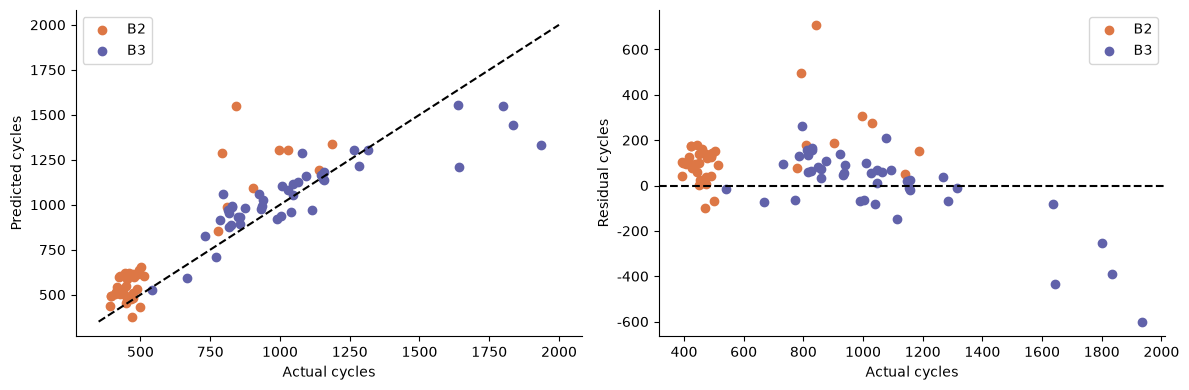

,stage,fold,cell,batch,actual,predicted,APE_pct
82,Test,NaN,B2-C45,B2,841.0,1549.374694,84.230047
55,Test,NaN,B2-C10,B2,791.0,1288.964395,62.953779
75,Test,NaN,B2-C32,B2,425.0,601.266195,41.474399
48,Test,NaN,B2-C03,B2,424.0,599.044427,41.284063
50,Test,NaN,B2-C05,B2,444.0,622.638993,40.234007
59,Test,NaN,B2-C14,B2,460.0,620.752775,34.946255
122,Test,NaN,B3-C41,B3,796.0,1057.900266,32.902043
70,Test,NaN,B2-C27,B2,450.0,589.785325,31.063406
120,Test,NaN,B3-C39,B3,1935.0,1334.723437,31.022045
83,Test,NaN,B2-C46,B2,997.0,1304.028399,30.795226


In [6]:
# 예측값은 log10에서 실제 cycles로 되돌린 결과다.
pred = pd.read_csv(ROOT / '.cache/modeling/predictions.csv')
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# 외부 테스트만 골라 실측–예측과 잔차를 그린다.
for batch in ['B2', 'B3']:
    g = pred[(pred.batch == batch) & (pred.stage == 'Test')]
    axes[0].scatter(g.actual, g.predicted, label=batch, color=COLORS[batch])
    axes[1].scatter(g.actual, g.predicted - g.actual, label=batch, color=COLORS[batch])
axes[0].plot([350, 2000], [350, 2000], 'k--')
axes[0].set(xlabel='Actual cycles', ylabel='Predicted cycles')
axes[1].axhline(0, color='black', ls='--')
axes[1].set(xlabel='Actual cycles', ylabel='Residual cycles')
for ax in axes:
    ax.legend()
plt.tight_layout()
fig.savefig(ROOT / 'results/figures/day2_predictions.png', dpi=190, bbox_inches='tight')
plt.show()
# APE가 큰 셀은 원인 분석 대상으로 확인한다. 점수를 이유로 제외하지 않는다.
display(pred[pred.stage == 'Test'].sort_values('APE_pct', ascending=False).head(10))


### 배치별 오차와 원인 가설

B2의 MAPE는 **23.71%**, B3는 **10.36%**다. B2에서는 평균 **128.9사이클의 과대 예측**이 관측된다. B1에 없던 단수명 분포로의 외삽과 배치별 피처–수명 관계의 차이가 가능한 원인이다.

B2-C45는 실제 841사이클에 대해 약 1,549사이클, B2-C10은 실제 791사이클에 대해 약 1,289사이클을 예측했다. 두 셀은 단수명 영역으로의 외삽만으로 큰 오차를 설명하기 어렵다. ΔQ 곡선의 형태, 충전 프로토콜, 원본 기록의 품질을 함께 확인할 필요가 있다. 오차가 크다는 이유만으로 셀을 제거하지 않는다.

현재 모델은 B3에서 B2보다 성능이 좋다. 배치가 달라졌다는 이유만으로 성능이 항상 같은 방향으로 악화되는 것은 아니며, 수명 분포와 피처 관계를 함께 살펴야 한다. 논문 기준 9.1%와의 Gap은 성능표에 요구된 수치 비교다. 데이터와 분할 조건이 동일하지 않으므로 직접적인 우열 판단에는 한계가 있다.

### 개선 방향과 ESS 적용

설계한 용량 3개 → 용량·저항·온도 5개 → Core6의 단계별 비교는 위의 피처군별 최선 후보 표에서 확인한다. 추가 피처가 항상 성능을 높이는 것은 아니므로 개발 CV의 결과를 기준으로 판단한다. 후보 선택은 계속 B1 내부에서 수행하며 B2·B3 결과로 다시 튜닝하지 않는다.

전체 배치의 EDA와 탐색 실험이 선행되었으므로 현재 외부 평가를 새로 확보한 블라인드 평가로 보지는 않는다. 실제 BESS 운영에 적용하려면 현장 데이터의 외부 검증, 달력 열화와 팩 편차, 예측 불확실성, 운영 중 성능 모니터링이 추가로 필요하다.
